# MSME Financial Health Card

This notebook generates an interpretable Financial Health Card for an MSME using:

- Trained XGBoost model
- Probability calibration
- Financial Health Score
- Business dimension scores
- Credit Risk Score
- Loan Readiness

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import json
import joblib
import pandas as pd
import numpy as np

from src.health_score import *

In [3]:
with open("../models/financial_health_xgboost_pipeline.pkl", "rb") as f:
    pipeline = joblib.load(f)

with open("../models/calibrated_model.pkl", "rb") as f:
    calibrated_model = joblib.load(f)

In [4]:
test_df = pd.read_csv("../data/test_msmes_data.csv")
test_df.head()

,Business_Size,Business_Age,Industry_Type,Entity_Type,Monthly_GST_Sales,GST_Growth_Rate,GST_Filing_Delay,GST_Compliance_Rate,Monthly_UPI_Count,Monthly_UPI_Value,...,Average_Bank_Balance,Monthly_Credit,Monthly_Debit,Cashflow_Volatility,Employee_Count,Payroll_Consistency,Vendor_Payment_Delay,Working_Capital_Cycle,EMI_Bounce_Count,Default
0,Micro,15.933212,Manufacturing,Proprietorship,1.991011e+06,0.132967,40.603347,0.753522,18,23182.735147,...,383551.492966,2.052574e+06,1.334769e+06,0.109957,7,0.762920,26.026572,86.793684,0,0
1,Micro,13.372797,Agriculture,Proprietorship,1.957794e+05,-0.112710,8.288537,0.941935,7,7847.904252,...,21445.075390,1.842835e+05,1.153964e+05,0.170288,3,0.680783,14.296041,73.378358,0,0
2,Micro,5.020739,Agriculture,Proprietorship,1.365257e+06,0.080203,36.889934,0.770537,9,6244.449405,...,91206.835004,1.283435e+06,1.042506e+06,0.301809,6,0.825411,19.029009,76.559823,0,1
3,Micro,1.591534,Services,Proprietorship,6.169990e+05,0.276537,3.240039,0.990259,35,63415.407028,...,37514.651954,6.458464e+05,3.896532e+05,0.348518,5,0.780057,10.701551,46.035540,0,0
4,Micro,9.934882,Retail,LLP,2.055470e+05,0.113028,8.198085,1.000000,33,68307.277542,...,29656.984152,1.800904e+05,1.093337e+05,0.070053,4,0.782431,17.896574,27.103863,0,0


## Compute health score for every customer

In [5]:
import pandas as pd

df = test_df.sample(1000).reset_index(drop = True)
health_results = []

for i, row in df.iterrows():
    print(i, end = " ")
    
    # Predict default probability
    X = row.drop("Default")

    pd_default = calibrated_model.predict_proba(
        pd.DataFrame([X])
    )[:,1][0]

    row["calibrated_pd"] = pd_default

    result = compute_financial_health_score(row)

    health_results.append({
        "overall": result["overall"],
        "business_health": result["business_health"],
        "credit_risk": result["credit_risk"],
        "grade": result["grade"],
        "loan_readiness": result["loan_readiness"],
        "Default": row["Default"],
        "calibrated_pd": row["calibrated_pd"]
    })

results_df = pd.DataFrame(health_results)

0 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 261 262 263 264 265 266 267 268 269 270 271 272 273 274 275 276 27

In [6]:
results_df.head()

,overall,business_health,credit_risk,grade,loan_readiness,Default,calibrated_pd
0,77.20,54.43,99.96,A,REVIEW,0,0.000444
1,74.80,50.25,99.35,A,REVIEW,0,0.006454
2,70.79,48.70,92.88,A,REVIEW,0,0.071237
3,84.37,69.20,99.54,AA,FAST REVIEW,0,0.004587
4,75.38,52.30,98.46,A,REVIEW,0,0.015435


In [7]:
results_df["overall"].describe()

count    1000.00000
mean       73.21874
std        15.55152
min         6.84000
25%        70.92000
50%        78.39000
75%        82.55000
max        93.51000
Name: overall, dtype: float64

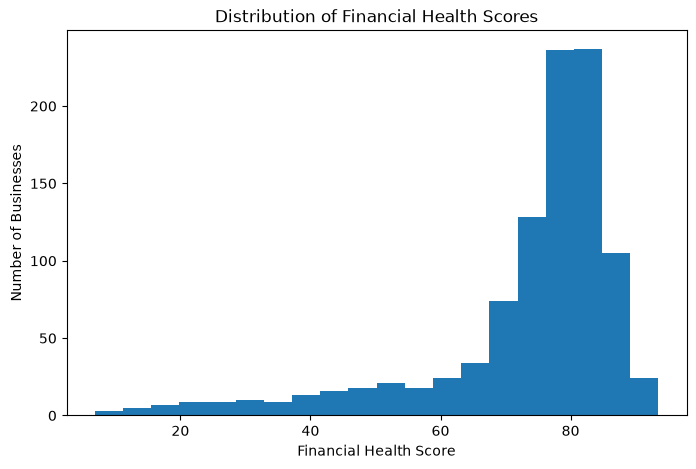

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(results_df["overall"], bins=20)
plt.xlabel("Financial Health Score")
plt.ylabel("Number of Businesses")
plt.title("Distribution of Financial Health Scores")
plt.show()

In [9]:
results_df.groupby("Default")["overall"].describe()

,count,mean,std,min,25%,50%,75%,max
Default,,,,,,,,
0,894.0,77.011935,9.676821,29.85,74.1675,79.14,83.095,93.51
1,106.0,41.227075,18.679251,6.84,25.6350,39.70,57.985,82.31


In [10]:
results_df[["overall", "calibrated_pd"]].corr()

,overall,calibrated_pd
overall,1.000000,-0.942214
calibrated_pd,-0.942214,1.000000


In [11]:
results_df["grade"].value_counts()

grade
AA           383
A            368
High Risk    142
BBB           90
AAA           17
Name: count, dtype: int64

In [12]:
results_df["loan_readiness"].value_counts()

loan_readiness
FAST REVIEW    383
REVIEW         368
NOT READY      232
READY           17
Name: count, dtype: int64

In [13]:
results_df.groupby("loan_readiness")["Default"].agg(
    count="count",
    defaults="sum",
    default_rate="mean"
)



,count,defaults,default_rate
loan_readiness,,,
FAST REVIEW,383,2,0.005222
NOT READY,232,100,0.431034
READY,17,0,0.000000
REVIEW,368,4,0.010870


In [14]:
from sklearn.metrics import roc_auc_score

risk_score = 100 - results_df["overall"]

auc = roc_auc_score(results_df["Default"], risk_score)

print("Health Score ROC-AUC:", round(auc, 3))

Health Score ROC-AUC: 0.953


## Single Customer Analysis

In [23]:
customer = df.iloc[8].copy()
customer

Business_Size                    Micro
Business_Age                  4.803147
Industry_Type              Hospitality
Entity_Type                Partnership
Monthly_GST_Sales        186728.048466
GST_Growth_Rate               0.092483
GST_Filing_Delay              3.438631
GST_Compliance_Rate                1.0
Monthly_UPI_Count                   43
Monthly_UPI_Value         27885.248904
Digital_Sales_Ratio           0.640509
Average_Bank_Balance       18102.95077
Monthly_Credit           186847.464071
Monthly_Debit            113051.088952
Cashflow_Volatility           0.465729
Employee_Count                       1
Payroll_Consistency           0.722618
Vendor_Payment_Delay         14.822845
Working_Capital_Cycle        39.644575
EMI_Bounce_Count                     0
Default                              0
Name: 8, dtype: object

In [25]:
# import json
# print(json.dumps(customer.to_dict(), indent=4))

In [26]:
# Predict default probability
X = customer.drop("Default")

pd_default = calibrated_model.predict_proba(
    pd.DataFrame([X])
)[:,1][0]

customer["calibrated_pd"] = pd_default

In [27]:
card = compute_financial_health_score(customer)

In [28]:
health_df = pd.DataFrame({
    "Metric":[
        "Cash Flow",
        "Compliance",
        "Operational",
        "Digital",
        "Stability",
        "Business Health",
        "Credit Risk",
        "Overall Score",
        "Grade",
        "Loan Readiness"
    ],
    "Value":[
        card["scores"]["cash_flow"],
        card["scores"]["compliance"],
        card["scores"]["operational"],
        card["scores"]["digital"],
        card["scores"]["stability"],
        card["business_health"],
        card["credit_risk"],
        card["overall"],
        card["grade"],
        card["loan_readiness"]
    ]
})

health_df

,Metric,Value
0,Cash Flow,30.69
1,Compliance,97.0
2,Operational,55.31
3,Digital,58.63
4,Stability,19.64
5,Business Health,58.51
6,Credit Risk,99.6
7,Overall Score,79.06
8,Grade,A
9,Loan Readiness,REVIEW


In [29]:
labels = list(card["scores"].keys())
values = list(card["scores"].values())

## Risk Summary

In [30]:
print(f"""
Overall Financial Health Score : {card['overall']}

Grade : {card['grade']}

Loan Readiness : {card['loan_readiness']}

Estimated Probability of Default :
{customer['calibrated_pd']:.2%}
""")


Overall Financial Health Score : 79.06

Grade : A

Loan Readiness : REVIEW

Estimated Probability of Default :
0.40%



## Strengths and Weaknesses

In [24]:
scores = card["scores"]

best = max(scores, key=scores.get)
worst = min(scores, key=scores.get)

print("Strongest Dimension:", best)
print("Weakest Dimension:", worst)

Strongest Dimension: compliance
Weakest Dimension: cash_flow


## Improvement Recommendations

In [25]:
recommendations = []

if card["scores"]["cash_flow"] < 70:
    recommendations.append(
        "Improve cash reserves and maintain stable monthly cash flow."
    )

if card["scores"]["compliance"] < 70:
    recommendations.append(
        "Improve GST compliance and reduce filing delays."
    )

if card["scores"]["operational"] < 70:
    recommendations.append(
        "Reduce vendor payment delays and improve working capital efficiency."
    )

if card["scores"]["digital"] < 70:
    recommendations.append(
        "Increase digital transactions and UPI adoption."
    )

if card["scores"]["stability"] < 70:
    recommendations.append(
        "Strengthen business stability through workforce and payroll consistency."
    )

recommendations

['Improve cash reserves and maintain stable monthly cash flow.',
 'Reduce vendor payment delays and improve working capital efficiency.',
 'Strengthen business stability through workforce and payroll consistency.']